# Module 3 — Migration Matrix & Early Warning
**Mục đích:** Theo dõi sự dịch chuyển nhóm nợ qua các kỳ — phát hiện xu hướng xấu đi sớm.

**Kỹ thuật:** `LAG() OVER (PARTITION BY id ORDER BY issue_month)`

**Ngưỡng cảnh báo:** Downgrade Nhóm 1→2 > 3% trong tháng → ALERT_RED


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Kết nối DuckDB → PostgreSQL ───────────────────────────────────────────────
PG = "dbname=risk_banking user=namphuong password=2104 host=localhost port=5432"
conn = duckdb.connect()
conn.execute("INSTALL postgres_scanner; LOAD postgres_scanner;")
conn.execute(f"ATTACH '{PG}' AS pg (TYPE postgres);")

# ── Style cho chart ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
})
COLORS = {
    "navy":   "#1D4E89", "blue":  "#2E86AB",
    "teal":   "#1D9E75", "green": "#27AE60",
    "amber":  "#E67E22", "red":   "#C0392B",
    "purple": "#8E44AD", "gray":  "#5D6D7E",
}
print("✓ Kết nối thành công — sẵn sàng phân tích")

✓ Kết nối thành công — sẵn sàng phân tích


## 3.1 — Migration Matrix tổng hợp

In [2]:
df_mig = conn.execute("""
    WITH grade_mapped AS (
        SELECT
            id, issue_month, loan_amnt, debt_group,
            CASE grade
                WHEN 'A' THEN 1
                WHEN 'B' THEN 2
                WHEN 'C' THEN 3
                WHEN 'D' THEN 3
                WHEN 'E' THEN 4
                WHEN 'F' THEN 4
                WHEN 'G' THEN 5
                ELSE 3
            END AS initial_risk_group
        FROM pg.accepted_loans
        WHERE grade IS NOT NULL AND debt_group IS NOT NULL
    )
    SELECT
        initial_risk_group  AS group_prev,
        debt_group          AS group_current,
        COUNT(*)            AS loan_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (
            PARTITION BY initial_risk_group), 4) AS migration_pct,
        CASE
            WHEN debt_group > initial_risk_group THEN 'Downgrade'
            WHEN debt_group < initial_risk_group THEN 'Upgrade'
            ELSE 'Stable'
        END AS direction
    FROM grade_mapped
    GROUP BY initial_risk_group, debt_group
    ORDER BY initial_risk_group, debt_group
""").df()

matrix = df_mig.pivot(
    index="group_prev",
    columns="group_current",
    values="migration_pct"
).fillna(0)

matrix.index   = matrix.index.astype(int)
matrix.columns = matrix.columns.astype(int)
all_groups = [1, 2, 3, 4, 5]
matrix = matrix.reindex(index=all_groups, columns=all_groups, fill_value=0)

print("=== Migration Matrix — Grade ban dau vs Nhom no thuc te (%) ===")
print(matrix.round(2).to_string())
diag_vals = [matrix.iloc[i,i] for i in range(5) if matrix.iloc[i,i] > 0]
if diag_vals:
    print(f"\nDiagonal (Stable rate) trung binh: {sum(diag_vals)/len(diag_vals):.2f}%")
print(f"Tong so loans: {df_mig.loan_count.sum():,}")


=== Migration Matrix — Grade ban dau vs Nhom no thuc te (%) ===
group_current      1     2     3    4      5
group_prev                                  
1              96.19  0.22  0.31  0.0   3.28
2              90.94  0.42  0.72  0.0   7.92
3              82.93  0.75  1.26  0.0  15.05
4              69.05  0.88  1.58  0.0  28.48
5              59.43  1.16  1.94  0.0  37.48

Diagonal (Stable rate) trung binh: 27.07%
Tong so loans: 2,260,668


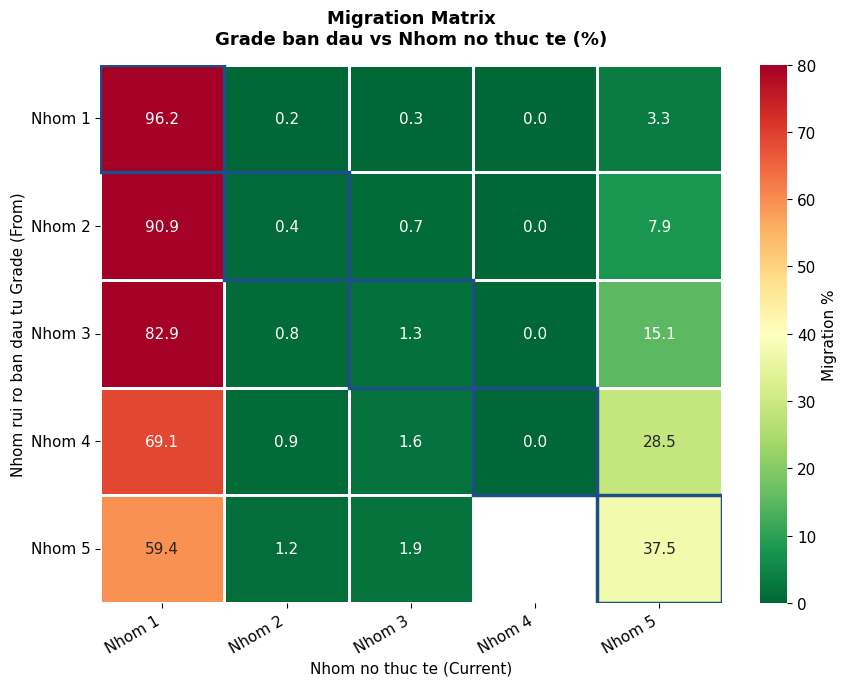

Da luu: m3_migration_matrix.png


In [3]:
import numpy as np

fig, ax = plt.subplots(figsize=(9, 7))

mask = matrix.values == 0

sns.heatmap(
    matrix,
    annot=True, fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.8, linecolor="white",
    cbar_kws={"label": "Migration %"},
    ax=ax, vmin=0, vmax=80,
    mask=mask,
    annot_kws={"size": 11},
)

ax.set_title("Migration Matrix\nGrade ban dau vs Nhom no thuc te (%)", pad=15, fontsize=13)
ax.set_xlabel("Nhom no thuc te (Current)", fontsize=11)
ax.set_ylabel("Nhom rui ro ban dau tu Grade (From)", fontsize=11)

group_labels = ["Nhom 1", "Nhom 2", "Nhom 3", "Nhom 4", "Nhom 5"]
ax.set_xticklabels(group_labels, rotation=30, ha="right")
ax.set_yticklabels(group_labels, rotation=0)

for i in range(5):
    if matrix.iloc[i, i] > 0:
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                      edgecolor=COLORS["navy"], lw=2.5))

plt.tight_layout()
plt.savefig("m3_migration_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Da luu: m3_migration_matrix.png")


## 3.2 — Downgrade Trend theo tháng

=== Downgrade Trend theo nam cohort ===
issue_year  total_loans  bad_loans  watch_loans  npl_rate  watch_rate  downgrade_rate       alert
      2007          603       45.0          0.0    7.4627      0.0000          7.4627    OK_GREEN
      2008         2393      247.0          0.0   10.3218      0.0000         10.3218 WATCH_AMBER
      2009         5281      594.0          0.0   11.2479      0.0000         11.2479 WATCH_AMBER
      2010        12537     1487.0          0.0   11.8609      0.0000         11.8609 WATCH_AMBER
      2011        21721     3297.0          0.0   15.1789      0.0000         15.1789 WATCH_AMBER
      2012        53367     8644.0          0.0   16.1973      0.0000         16.1973 WATCH_AMBER
      2013       134814    21027.0          1.0   15.5970      0.0007         15.5978 WATCH_AMBER
      2014       235629    41496.0        273.0   17.6107      0.1159         17.7266 WATCH_AMBER
      2015       421095    77163.0        891.0   18.3244      0.2116         

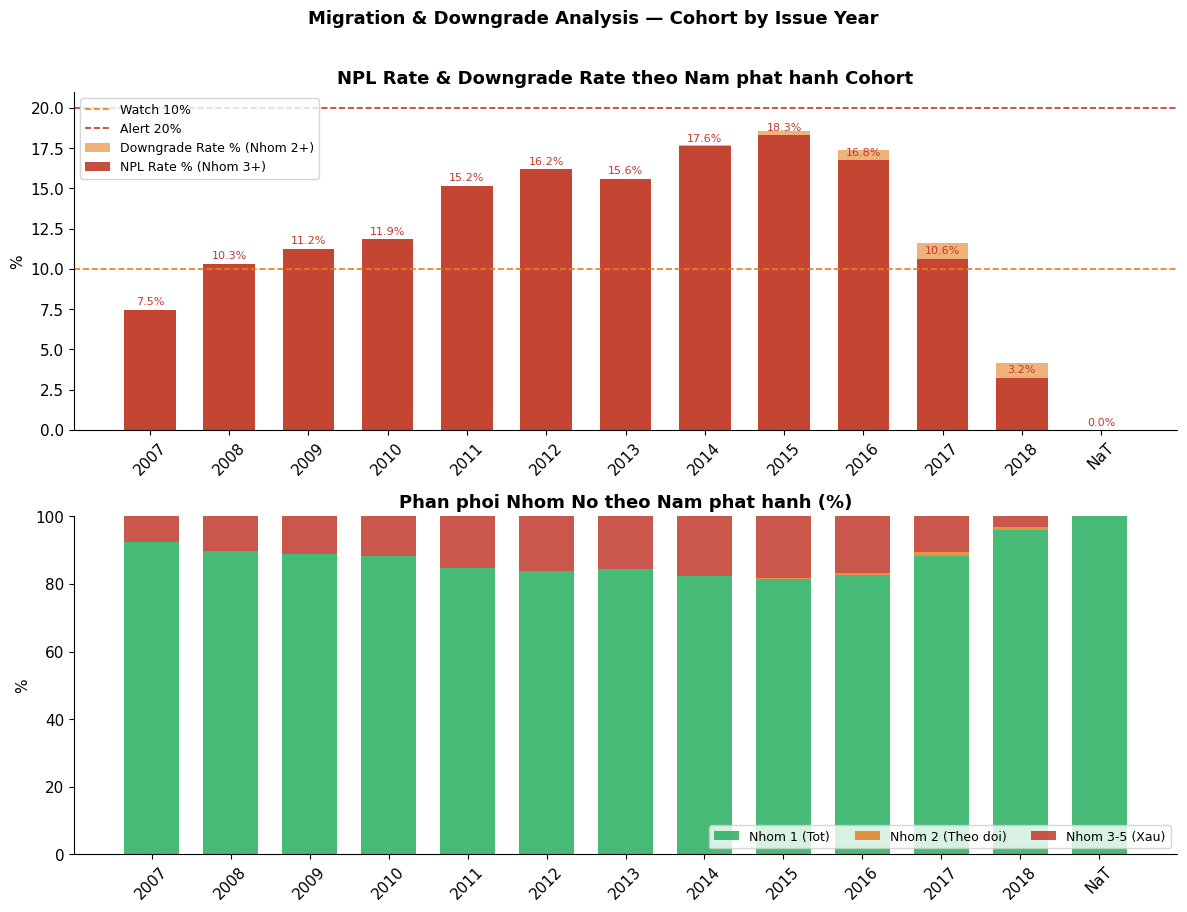


Nam ALERT_RED (NPL > 20%): []


In [4]:
df_dg = conn.execute("""
    SELECT
        SUBSTR(issue_month, 1, 4)                              AS issue_year,
        COUNT(*)                                               AS total_loans,
        SUM(CASE WHEN debt_group >= 3 THEN 1 ELSE 0 END)      AS bad_loans,
        SUM(CASE WHEN debt_group = 2  THEN 1 ELSE 0 END)      AS watch_loans,
        ROUND(100.0 * SUM(CASE WHEN debt_group >= 3
            THEN 1 ELSE 0 END) / COUNT(*), 4)                 AS npl_rate,
        ROUND(100.0 * SUM(CASE WHEN debt_group = 2
            THEN 1 ELSE 0 END) / COUNT(*), 4)                 AS watch_rate,
        ROUND(100.0 * SUM(CASE WHEN debt_group >= 2
            THEN 1 ELSE 0 END) / COUNT(*), 4)                 AS downgrade_rate,
        CASE
            WHEN 100.0 * SUM(CASE WHEN debt_group >= 3
                THEN 1 ELSE 0 END) / COUNT(*) > 20 THEN 'ALERT_RED'
            WHEN 100.0 * SUM(CASE WHEN debt_group >= 3
                THEN 1 ELSE 0 END) / COUNT(*) > 10 THEN 'WATCH_AMBER'
            ELSE 'OK_GREEN'
        END AS alert
    FROM pg.accepted_loans
    WHERE issue_month IS NOT NULL
    GROUP BY SUBSTR(issue_month, 1, 4)
    ORDER BY issue_year
""").df()

print("=== Downgrade Trend theo nam cohort ===")
print(df_dg.to_string(index=False))

x     = df_dg["issue_year"].tolist()
x_num = list(range(len(x)))

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Chart 1: Bar NPL + Downgrade
axes[0].bar(x_num, df_dg["downgrade_rate"], color=COLORS["amber"],
            alpha=0.6, label="Downgrade Rate % (Nhom 2+)", width=0.65)
axes[0].bar(x_num, df_dg["npl_rate"], color=COLORS["red"],
            alpha=0.9, label="NPL Rate % (Nhom 3+)", width=0.65)
axes[0].axhline(10, color=COLORS["amber"], linestyle="--", linewidth=1.2, label="Watch 10%")
axes[0].axhline(20, color=COLORS["red"],   linestyle="--", linewidth=1.2, label="Alert 20%")
axes[0].set_xticks(x_num)
axes[0].set_xticklabels(x, rotation=45)
axes[0].set_title("NPL Rate & Downgrade Rate theo Nam phat hanh Cohort")
axes[0].set_ylabel("%")
axes[0].legend(loc="upper left", fontsize=9)
for i, v in enumerate(df_dg["npl_rate"]):
    axes[0].text(i, float(v) + 0.3, f"{float(v):.1f}%",
                 ha="center", fontsize=8, color=COLORS["red"])

# Chart 2: Stacked bar phan phoi nhom no
good_vals  = (100 - df_dg["downgrade_rate"]).astype(float).tolist()
watch_vals = df_dg["watch_rate"].astype(float).tolist()
bad_vals   = df_dg["npl_rate"].astype(float).tolist()
bottom_w   = good_vals
bottom_b   = [g + w for g, w in zip(good_vals, watch_vals)]

axes[1].bar(x_num, good_vals,  color=COLORS["green"], label="Nhom 1 (Tot)",    width=0.7, alpha=0.85)
axes[1].bar(x_num, watch_vals, color=COLORS["amber"], label="Nhom 2 (Theo doi)",
            bottom=bottom_w, width=0.7, alpha=0.85)
axes[1].bar(x_num, bad_vals,   color=COLORS["red"],   label="Nhom 3-5 (Xau)",
            bottom=bottom_b, width=0.7, alpha=0.85)
axes[1].set_xticks(x_num)
axes[1].set_xticklabels(x, rotation=45)
axes[1].set_title("Phan phoi Nhom No theo Nam phat hanh (%)")
axes[1].set_ylabel("%")
axes[1].legend(loc="lower right", ncol=3, fontsize=9)

plt.suptitle("Migration & Downgrade Analysis — Cohort by Issue Year",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("m3_downgrade_trend.png", dpi=150, bbox_inches="tight")
plt.show()

alert_years = df_dg[df_dg["alert"] == "ALERT_RED"]["issue_year"].tolist()
print(f"\nNam ALERT_RED (NPL > 20%): {alert_years}")
